In [2]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [3]:
X,y= make_regression(100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

In [4]:
X.shape,y.shape     

((100, 1), (100,))

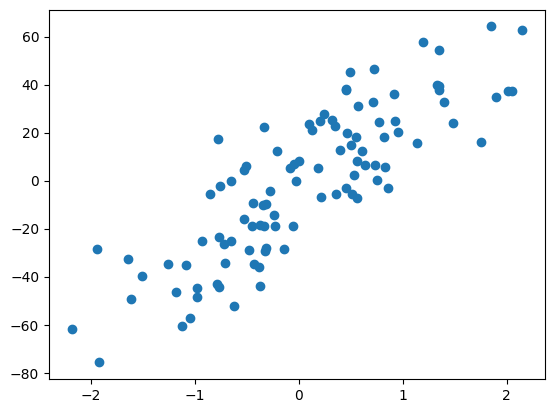

In [5]:
plt.scatter(X,y)

In [6]:
from sklearn.linear_model import LinearRegression


In [7]:
lr = LinearRegression()
lr.fit(X,y)
    

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
lr.coef_,lr.intercept_

(array([27.82809103]), np.float64(-2.29474455867698))

In [9]:
from sklearn.linear_model import Ridge
lr1=Ridge(alpha=10)
lr1.fit(X,y)  
lr1.coef_,lr1.intercept_

(array([24.9546267]), np.float64(-2.1269130035235735))

In [10]:
lr2=Ridge(alpha=100)
lr2.fit(X,y)  
lr2.coef_,lr2.intercept_

(array([12.93442104]), np.float64(-1.4248441496033308))

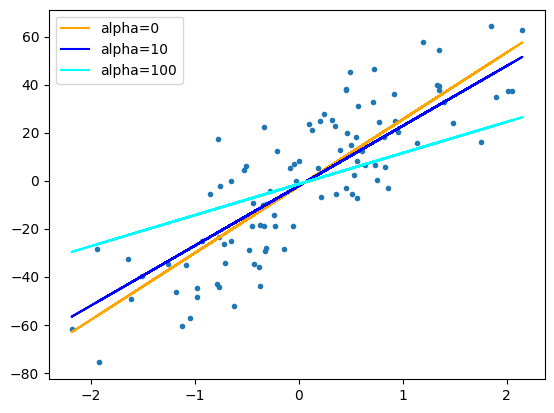

In [13]:
plt.plot(X,y,'.')
plt.plot(X,lr.predict(X),color='orange',label='alpha=0')
plt.plot(X,lr1.predict(X),color='blue',label='alpha=10')
plt.plot(X,lr2.predict(X),color='cyan',label='alpha=100')
plt.legend()

In [15]:
X.shape

(100, 1)

In [16]:
def linear_reg(X,y,alpha=1):

    X_mean=X.mean()
    y_mean=y.mean()
    num=0
    den=0
    for i in range(0,len(X)):
        num=(y_mean-y[i])*(X[i]-X_mean)+num
        den=(X_mean-X[i])*(X[i]-X_mean)+den

    m=num/den
    b=y_mean-alpha*X_mean
    return m,b

In [22]:
len(X)

100

In [23]:
class Mera_Ridge:
    def __init__(self,alpha=0.1):
        self.alpha=None
        self.m=None
        self.b=None
    def fit(self,X_train,y_train):
        X_mean=X_train.mean()
        y_mean=y_train.mean()

        den=0
        num=0
        for i in range(0,len(X_train)):
            num=num+(y_mean-y_train[i])*(X_train[i]-X_mean)
            den=den+(X_mean-X_train[i]*(X_mean-X_train[i]))
        self.m=num/(den+self.alpha)
        self.b=y_mean-self.m*X_mean
        
    def predict(self,X_test):
        return self.m*X_test +self.b



In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y)